#Demo de Agentes para jugar al Blackjack (21) usando primero Q-Learning y luego una Deep-Q-Network (DQN)

 Inicialmente basado en los tutoriales de Tensor Flow: https://www.tensorflow.org/agents/tutorials/1_dqn_tutorial pero ahora no se usa TF-Agents por problemas de compatbilidad con TF-Keras 3

 En esta nueva versión se hace compatible con Gymnasium: https://gymnasium.farama.org/

In [ ]:
#@title Cargar Librerías


import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
from random import randint
import pandas as pd
import os

from typing import Optional
import gymnasium as gym

print("Librerías cargadas.")

Librerías cargadas.


## Clases sobre el Problema a resolver

In [ ]:
#@title Definir Entorno del Problema

# Un entorno que represente el juego podría verse así:
##Acciones: Tenemos dos acciones.
##             Acción 0: obtener una nueva carta
##             Acción 1: terminar la ronda actual.
##Observaciones: Suma de las cartas de la ronda actual.
##Recompensa: El objetivo es acercarse lo más posible a 21 sin pasarse,
##            por lo que podemos lograrlo usando la siguiente recompensa al final de la ronda:
##            suma_de_tarjetas - 21 si suma_de_tarjetas <= 21, de lo contrario -21

accion_pedirCarta = 1
accion_plantar = 0
posiblesAccionesDescrip = [ "se planta", "pide carta"]
posiblesEstadosDescrip = ['SUMA={:}'.format(x) for x in range(0, 33)]
posiblesCartas = ['-', 'As', '#2', '#3', '#4', '#5', '#6', '#7', '#8', '#9', '#10', 'J', 'Q', 'K']

# Un entorno que represente el juego podría verse así:
class CardGameEnv(gym.Env):

  def __init__(self):
    # las acciones
    self.action_space = gym.spaces.Discrete(len(posiblesAccionesDescrip))
    # la observación es el estado actual de la máquina
    self.observation_space = gym.spaces.Discrete(len(posiblesEstadosDescrip))
    # resetea el entorno
    self.reset()

  # métodos estáticas para registración del modelo
  @staticmethod
  def getEnvID():
    return "demoRL/CardGameEnv-v1"

  @staticmethod
  def getEnvNonDeterministic():
    return True

  def _get_obs(self):
    # devuelve la observación del estado actual
    return self._state

  def _get_info(self, newCard=None):
    # devuelve información adicional sobre el estado actual
    auxInfo = { }
    auxInfo["stateId"] = self._state
    if (self._state>=0) and (self._state < len(posiblesEstadosDescrip)):
      auxInfo["stateName"] = posiblesEstadosDescrip[self._state]
    else:
      auxInfo["stateName"] = "id:"+str(self._state)
    auxInfo["reward"] = self._reward
    auxInfo["episodeTerminated"] = self._episodeTerminated
    auxInfo["episodeTruncated"] = self._episodeTruncated
    auxInfo["cantIteraciones"] = self._cantIteraciones
    auxInfo["lastActionId"] = self._lastActionId
    if (self._lastActionId is not None) and (self._lastActionId>=0) and (self._lastActionId < len(posiblesAccionesDescrip)):
      auxInfo["lastActionName"] = posiblesAccionesDescrip[self._lastActionId]
    if (self._lastNewCard is not None):
        auxInfo["newCard"] = self._lastNewCard
    return auxInfo

  def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
    # resetea el entorno
    if seed is None:
      seed=123
    super().reset(seed=seed)
    self._state = 0
    self._cantIteraciones = 0
    self._episodeTerminated = False
    self._episodeTruncated = False
    self._reward = 0.0
    self._lastActionId = None
    self._lastNewCard = None
    # devuelve observación e info actual
    self._lastObs = self._get_obs()
    self._lastInfo = self._get_info()
    return self._lastObs, self._lastInfo

  def step(self, action):
    # aplica una acción sobre el entorno
    if self._episodeTerminated or self._episodeTruncated:
      # si el entorno ya está finalizado, lo resetea
      return self.reset()
    self._lastActionId = action
    # Aplica la acción
    if action == accion_plantar:
      # indica no seguir jugando
      self._episodeTerminated = True
      new_card = 0
    elif action == accion_pedirCarta:
      # solicita una carta
      new_card = randint(1, 12)
      if new_card == 1:
        # el as puede valer 1 o 11
        if (self._state + 11) < 21:
          self._state = self._state + 11
        else:
          self._state = self._state + 1
      elif new_card >= 10:
        # las figuras valen 10
        self._state = self._state + 10
      else:
        # el resto vale su valor
        self._state = self._state + new_card
      # se llega a un valor de 21, no se puede pedir más
      if self._state >= 21:
        self._episodeTerminated = True
    else:
      raise ValueError('La acción debe ser 0 o 1.')
    self._lastNewCard = new_card
    # determina reward
    if self._episodeTerminated:
      # si finaliza
      # determina el reward (siempre se maximiza)
      # en este caso el máximo es 21!
      if self._state > 21:
        # se paso de 21, devuelve cantidad que se paso (negativo)
        self._reward = float(21 - self._state)
      else:
        # no se paso de 21 (devuelve a donde llegó)
        self._reward = float(self._state)
    else:
      # si no finaliza
      self._cantIteraciones = self._cantIteraciones - 1
      self._reward = 0.0
    self._episodeTruncated = False # no se usa para este entorno
    # devuelve observacón e info actual, reward y si terminó
    self._lastObs = self._get_obs()
    self._lastInfo = self._get_info()
    return self._lastObs, self._reward, self._episodeTerminated, self._episodeTruncated, self._lastInfo

  # muestra la situación actual del entrono
  def render(self):
    if self._episodeTerminated:
      sitEpisode = "Fin"
    elif self._episodeTruncated:
      sitEpisode = "Fin Forzado"
    elif self._cantIteraciones==0:
      sitEpisode = "Ini"
    else:
      sitEpisode = "#"+str(abs(self._cantIteraciones))
    # muestra información
    textoRender = " " + sitEpisode + ": "
    if (self._lastActionId is not None):
      textoRender += posiblesAccionesDescrip[self._lastActionId] + ": "
      textoRender += posiblesCartas[self._lastNewCard] + " -> "
    textoRender += "Estado " + posiblesEstadosDescrip[self._lastObs]
    if self._lastObs>21:
      textoRender += " PIERDE!"
    print(textoRender)
    return textoRender

# registra el entorno
gym.register(
    id = CardGameEnv.getEnvID(),
    entry_point = CardGameEnv,
    nondeterministic = CardGameEnv.getEnvNonDeterministic())
    #max_episode_steps = CardGameEnv.getEnvMaxSteps()

# Inicializa el entorno de entrenamiento y evaluación
envProblema = gym.make( CardGameEnv.getEnvID() )

print("Entorno del Problema definido.")


# Clase para Agente que juega al azar
# lo único que considera son las posibles acciones a realizar
# para elegir una al azar
class RandomAgentClass():

  def __init__(self, observation_space, action_space):
    self._action_space = action_space

  def action(self, observation=None, info=None):
      # devuelve una acción al azar
      return self._action_space.sample()

randomAgent = RandomAgentClass(envProblema.observation_space,
                                                envProblema.action_space)

print("Agente Random definido para el entorno. ")


# funciones auxiliares para simular la ejecución del entorno

def mostrarObsInfoStep(env_obs, env_info, action_step=None):
  print("\t", end=" ")
  if action_step is not None:
    print("action_step {}".format(action_step), end=" -> ")
  print("env obs {} & info {}".format(env_obs, env_info))

# definir simulador para probar el entorno
def SimularEntorno(env, ag, titulo="", mostrarRender=True, mostrarResultado=True, mostarInfoStep=False):
    if len(titulo)>0:
      print("\n** ", titulo, "**")
    # inicializa variables
    done = False
    actionList = []
    # resetea el entorno
    env_obs, env_info  = env.reset()
    if mostrarRender:
      env.render()
      if mostarInfoStep:
        mostrarObsInfoStep(env_obs, env_info)
    while not done:
      # el agente determina la acción a realizar
      action_step = ag.action(env_obs, env_info)
      # se ejecuta la acción en el entorno
      env_obs, env_reward, env_terminated, env_truncated, env_info = env.step( action_step )
      actionList.append(action_step)
      if mostrarRender:
        env.render()
        if mostarInfoStep:
          mostrarObsInfoStep(env_obs, env_info, action_step)
      # determina si finaliza la simulación
      done = env_terminated or env_truncated
    if mostrarResultado:
      # muestra resultaodos finales
      print(" -Recompensa Final = " + str(round(env_reward, 3)))
      print(" -Secuencia de Acciones = " + " + ".join([posiblesAccionesDescrip[ac] for ac in actionList]))
    return env_reward

# función auxiliar para comparar
def compararRtdosAgentes(cantidad_probar, envProblema, ag1, ag2, descAg1="Agente 1", descAg2="Agente 2"):
  prom1 = 0
  prom2 = 0
  for i in range(cantidad_probar):
    print("\n> Prueba ", i+1, ":")
    # Probar 1
    valor1 = SimularEntorno(envProblema, ag1, "Resultados de " + descAg1, mostrarRender=False, mostrarResultado=True)
    prom1 = prom1 + valor1
    # Probar 2
    valor2 = SimularEntorno(envProblema, ag2, "Resultados de " + descAg2, mostrarRender=False, mostrarResultado=True)
    prom2 = prom2 + valor2
    # Decide Ganador
    strMostrar = "\n--> " + descAg1 + " (%s) genera" % valor1
    if valor1 > valor2:
      strMostrar = strMostrar + " MEJOR "
    elif valor1 < valor2:
      strMostrar = strMostrar + " PEOR "
    else:
      strMostrar = strMostrar + " IGUAL "
    strMostrar = strMostrar + "resultado que " + descAg2 + " (%s)." % valor2
    print(strMostrar)
  # Decide Ganador General
  if cantidad_probar > 0:
    prom1 = prom1 / cantidad_probar
    prom2 = prom2 / cantidad_probar
    print("\n================================================================================================\n")
    strMostrar = " * En Promedio " + descAg1 + " (%s) genera" % prom1
    if prom1 > prom2:
      strMostrar = strMostrar + " MEJORES "
    elif prom1 < prom2:
      strMostrar = strMostrar + " PEORES "
    else:
      strMostrar = strMostrar + " IGUALES "
    strMostrar = strMostrar + "resultados que " + descAg2 + " (%s)." % prom2
    print(strMostrar)
    print("\n================================================================================================\n")

print("Simulador del entorno definido.")

# Probar el entorno definido con Política Aleatoria (opcional)
Probar_Entorno = True #@param {type:"boolean"}
MostarDetalleSteps = False #@param {type:"boolean"}

if Probar_Entorno:
  SimularEntorno(envProblema, randomAgent, "Probando el entorno del problema al azar", mostarInfoStep=MostarDetalleSteps)


Entorno del Problema definido.
Agente Random definido para el entorno. 
Simulador del entorno definido.

**  Probando el entorno del problema al azar **
 Ini: Estado SUMA=0
 Fin: se planta: - -> Estado SUMA=0
 -Recompensa Final = 0.0
 -Secuencia de Acciones = se planta


##Q-Learning

In [ ]:
#@title Define clase Agente Q-Learning

from typing import Optional, Text

# devuelve valor unico en base a vector OBS
# para determinar fila de estado
def generarNroEstadoVector(obs):
  ntarget = np.array(obs).flatten()
  valorTotal = 0
  for i in range(1, len(ntarget)):
    if ntarget[i] == -1:
      valorTotal = valorTotal + 2**i
    elif ntarget[i] == 1:
      valorTotal = valorTotal + 3**i
  return valorTotal

# devuelve la cantidad de estados máxima
# que se pueden generar usando un ejemplo
# del vector de OBS
def calcMaxNroEstadoVector(ejemploObs):
  ntarget = np.array(ejemploObs).flatten()
  cant = len(ntarget)
  return ( 3**cant + 2**cant + 1 )


# Clase para Agente Q-Learning
class QLAgentClass():

  def __init__(self,
               posiblesEstadosList,
               posiblesAccionesList,
               observation_space,
               action_space):
      # controla información recibida
      ##if obsIdEstado not in observation_space.keys():
      ##  raise ValueError( "No se encuentra definición de estado "+str(obsIdEstado)+" en observation_space!")
      if (posiblesEstadosList is None) or (len(posiblesEstadosList)<2):
       raise ValueError('No se ha definida la lista de posibles estados!' )
      if (posiblesAccionesList is None) or (len(posiblesAccionesList)<2):
       raise ValueError('No se ha definida la lista de posibles acciones!' )
      if len(posiblesEstadosList) != observation_space.n:
        raise ValueError("La cantidad de estados no coincide con definición de observation_space!")
      if len(posiblesAccionesList) != action_space.n:
        raise ValueError("La cantidad de acciones no coincide con definición de action_space!")
      # inicializa parametros de matriz
      ##self._obsIdEstado = obsIdEstado
      self._posiblesEstadosList = posiblesEstadosList
      self._cantEstados = len(posiblesEstadosList)
      self._posiblesAccionesList = posiblesAccionesList
      self._cantAcciones = len(posiblesAccionesList)
      self.ResetQ()

  # funcion auxiliar para inicializar la matriz
  def ResetQ(self):
      self._Qtable = np.zeros([self._cantEstados, self._cantAcciones])
      self._QtableEntrenada = False

  # función auxiliar de entrenamiento
  def TrainQ(self, env, train_policy, alpha = 0.1, gamma = 0.6, epsilon = 0.1, cant_ciclos_entrenamiento = 100000,
             log_cada_ciclos = 1000, mostrarDetalleAcciones=False):
      ##print(self._Qtable.shape)
      ##print(self._usarOBSVector)
      # ejecuta el entrenamiento
      for step in range(1, cant_ciclos_entrenamiento+1):
          # inicializa variables
          j = 1
          done = False
          # Resetea el enviroment
          env_obs, env_info = env.reset()
          state = env_obs
          secuenciaAcciones = ""
          # Simula
          while not done:
              # Considera lo aprendido o toma al azar depende de azar y epsilon
              if random.uniform(0, 1) < epsilon:
                  # toma de Matriz-Q
                  accionAplicar = np.argmax( self._Qtable[state] )
              else:
                  # toma al azar
                  accionAplicar = train_policy.action(env_obs, env_info)
              if j > 1:
                secuenciaAcciones = secuenciaAcciones + " + "
              secuenciaAcciones = secuenciaAcciones + self._posiblesAccionesList[ accionAplicar ]
              j = j + 1
              # Aplica la Accion
              env_obs, env_reward, env_terminated, env_truncated, env_info = env.step( accionAplicar )
              next_state = env_obs
              # Recalcula Q
              q_value = self._Qtable[state, accionAplicar]
              max_value = np.max(self._Qtable[next_state])
              new_q_value = (1 - alpha) * q_value + alpha * (env_reward + gamma * max_value)
              # Actualiza Matriz-Q
              self._Qtable[state, accionAplicar] = new_q_value
              state = next_state
              # termino realmente el juego
              # o se forzo la terminación por máximos pasos
              done = env_terminated or env_truncated
          # muestra estado
          if log_cada_ciclos > 0:
            if (step == 1) or (step % log_cada_ciclos == 0):
              if mostrarDetalleAcciones:
                print('step = {0}: Recompensa = {1} - Acciones({2}) = {3} '.format(step, env_reward, (j-1), secuenciaAcciones))
              else:
                print('step = {0}: Recompensa = {1} - Acciones({2}) '.format(step, env_reward, (j-1)))
      # Devuelve Matriz-Q
      self._QtableEntrenada = True
      return self._Qtable

  # obtiene Q-Table como DataFrame
  def getQ_DF(self):
        cm = self._Qtable
        cmtx = pd.DataFrame(
            cm,
            index=self._posiblesEstadosList,
            columns=self._posiblesAccionesList
          )
        return cmtx

  # graba Q-Table como CSV
  def saveQ(self, fileName):
        # obtiene data frame de matriz Q
        df = self.getQ_DF()
        # graba matriz Q como CSV
        df.to_csv(fileName, index=True)
        return

  # recupera Q-Table de CSV
  def loadQ(self, fileName):
        # lee matriz Q de CSV
        df = pd.read_csv(fileName)
        # carga elementos en memoria
          # saca nombre de estados
        self._posiblesEstadosList = list(df.pop(df.columns[0]))
          # acciones
        self._posiblesAccionesList = list(df.columns.tolist())
          # borra el primer elemento de titulo
        ##self._posiblesAccionesList = np.delete(self._posiblesAccionesList, 0, axis=0)
         # matriz Q
        self._Qtable = list(df.to_numpy())
        # re-inicializa las cantidades
        self._cantEstados = len(self._posiblesEstadosList)
        self._cantAcciones = len(self._posiblesAccionesList)
        self._QtableEntrenada = True
        # muestra resultados
        self.MostrarQ("Matriz-Q recuperada:")
        return

  # función auxiliar para mostrar matri Q
  def MostrarQ(self, titulo="Matriz-Q entrenada:", mostrarTexto=False):
        # muestra Q table
        cmtx = self.getQ_DF()
        if mostrarTexto:
          # agrega para poder mostrar la matrix de confusión completa
          pd.options.display.max_rows = 100
          pd.options.display.max_columns = 100
          print('\n ' + titulo + ' ')
          print(cmtx)
        else:
          def make_pretty(styler, vmin=1, vmax=100):
              styler.set_caption(titulo)
              styler.format(precision=3)
              styler.background_gradient(axis=None, cmap="Greys")
              return styler
          display(cmtx.style.pipe(make_pretty))
        print("\n")
        return

  # devuelve la accion que se debe aplicar usando la matrix Q entrenada
  def action(self, observation, info=None):
      # determina la accion a realizar
      # obtiene estado actual
      state = observation
      # toma de Matriz-Q
      accionAplicar = np.argmax( self._Qtable[state] )
      # devuelve la accion
      return accionAplicar


print("Clase QLAgentClass creada.")

# instancia de Q Learning
qlAgent = QLAgentClass(posiblesEstadosList = posiblesEstadosDescrip,
                         posiblesAccionesList = posiblesAccionesDescrip,
                         observation_space=envProblema.observation_space,
                         action_space=envProblema.action_space
                         ##obsIdEstado = envObsStateId
                         )

print("\nAgente QL inicializado. ")


Clase QLAgentClass creada.

Agente QL inicializado. 


In [ ]:
#@title Entrenar con algoritmo Q-Learning

# parámetros
entrenar_QL = True #@param {type:"boolean"}
#@markdown Hiper-parámetros:
alpha = 0.1 #@param {type:"number"}
gamma = 0.8 #@param {type:"number"}
epsilon = 0.6 #@param {type:"number"}
#@markdown Ciclos:
cant_episodios_entrenamiento_finalizar = 5000 #@param {type:"integer"}
mostar_recompensa_cada = 100  #@param {type:"integer"}

if alpha <= 0.0:
   alpha = 0.001
if gamma <= 0.0:
    gamma = 0.001
if epsilon <= 0.0:
   epsilon = 0.001
if cant_episodios_entrenamiento_finalizar <= 10:
   cant_episodios_entrenamiento_finalizar = 10
if mostar_recompensa_cada < 1:
  mostar_recompensa_cada = 1


if entrenar_QL:
  # resetea matriz q
  qlAgent.ResetQ()
  # hace el entrenamiento
  print("** Comienza el Entrenamiento **\n")
  qlAgent.TrainQ(env = envProblema,
                   train_policy = randomAgent,
                   alpha = alpha, gamma = gamma, epsilon = epsilon,
                   cant_ciclos_entrenamiento = cant_episodios_entrenamiento_finalizar,
                   log_cada_ciclos = mostar_recompensa_cada,
                   mostrarDetalleAcciones = True)
  print("\n** Entrenamiento Finalizado **")
  # muestra matriz
  qlAgent.MostrarQ()
else:
  print("No se ejecuta entrenamiento de Agente Q-Learning.")

** Comienza el Entrenamiento **

step = 1: Recompensa = 0.0 - Acciones(1) = se planta 
step = 100: Recompensa = 10.0 - Acciones(2) = pide carta + se planta 
step = 200: Recompensa = 0.0 - Acciones(1) = se planta 
step = 300: Recompensa = 5.0 - Acciones(2) = pide carta + se planta 
step = 400: Recompensa = 7.0 - Acciones(2) = pide carta + se planta 
step = 500: Recompensa = 13.0 - Acciones(3) = pide carta + pide carta + se planta 
step = 600: Recompensa = 0.0 - Acciones(1) = se planta 
step = 700: Recompensa = 2.0 - Acciones(2) = pide carta + se planta 
step = 800: Recompensa = 17.0 - Acciones(3) = pide carta + pide carta + se planta 
step = 900: Recompensa = 10.0 - Acciones(2) = pide carta + se planta 
step = 1000: Recompensa = 0.0 - Acciones(1) = se planta 
step = 1100: Recompensa = 10.0 - Acciones(2) = pide carta + se planta 
step = 1200: Recompensa = 0.0 - Acciones(1) = se planta 
step = 1300: Recompensa = 0.0 - Acciones(1) = se planta 
step = 1400: Recompensa = 10.0 - Acciones(2) =

,se planta,pide carta
SUMA=0,32.155,41.843
SUMA=1,0.000,0.000
SUMA=2,34.010,42.697
SUMA=3,36.205,44.013
SUMA=4,38.358,46.215
SUMA=5,40.903,46.301
SUMA=6,42.142,50.554
SUMA=7,45.566,50.155
SUMA=8,47.147,53.839
SUMA=9,47.040,52.068


In [ ]:
#@title Probar Q-Learning Entrenado contra el Azar
cantidad_probar = 10 # @param {type:"integer"}

if qlAgent is not None:
  compararRtdosAgentes(cantidad_probar, envProblema,
                      qlAgent, randomAgent,
                      "Agente Q-Learning", "el Azar")



> Prueba  1 :

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 11.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados de el Azar **
 -Recompensa Final = 14.0
 -Secuencia de Acciones = pide carta + pide carta + pide carta + se planta

--> Agente Q-Learning (11.0) genera PEOR resultado que el Azar (14.0).

> Prueba  2 :

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 14.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados de el Azar **
 -Recompensa Final = 17.0
 -Secuencia de Acciones = pide carta + pide carta + pide carta + se planta

--> Agente Q-Learning (14.0) genera PEOR resultado que el Azar (17.0).

> Prueba  3 :

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 14.0
 -Secuencia de Acciones = pide carta + pide carta + pide carta + se planta

**  Resultados de el Azar **
 -Recompensa Final = 0.0
 -Secuencia de Acciones = se planta

--> Agente Q-Learning (14.0) genera MEJOR resultado que el A

## Deep-Q-Network (DQN)

In [ ]:
#@title Define clase Agente DQN

import tensorflow as tf
from collections import deque

#@markdown ### Parámetros generales:
agent_config = "Personalizada" #@param ["DeepMind", "Personalizada"]

#@markdown ### Parámetros de las capas ConvNet:
dqn_convNet_usar = False #@param {type:"boolean"}
dqn_convNet_tamaño_kernel_N =  3 #@param {type:"integer"}
dqn_convNet_tamaño_pooling_M = 3 #@param {type:"integer"}
dqn_convNet_cantidad_capas_ocultas =  1#@param {type:"integer"}

#@markdown ### Parámetros de las capas Lineales:
dqn_lineal_cant_neuronas_capas_ocultas = '50' #@param {type:"string"}
#@markdown (Nota: se puede indicar Cantidad de neuronas, D para DropOut, BN para BatchNormalization)
dqn_lineal_tipo_funcion = 'relu' #@param ['exponential', 'linear', 'relu', 'sigmoid', 'tanh' ]
dqn_lineal_porc_capa_DropOut = 0.3 #@param {type:"number"}

#@markdown ### Parámetros del Optimizador:
opt_tipo = "Adam" #@param ["Gradiente Decreciente", "Adam", "Adadelta", "Adagrad", "Adamax", "RMSprop", "Momentum", "NAG", "Nadam"]
opt_learning_rate = 0.01 #@param {type: "number"}


# diccionario auxiliar para pasar configuracion QNetwork
config_q_network = {}

# tamaño de los kernels y pooling (para simplificar son todas iguales)
if agent_config.lower()=="deepmind":
    # usa red definido en paper original de DeepMind
    config_q_network["cnn_deepmind_config"] = True
else:
    # usa red con configuración definida por parámetros
    config_q_network["cnn_deepmind_config"] = False
    config_q_network["cnn_use"] = dqn_convNet_usar
    if dqn_convNet_tamaño_kernel_N<1:
      dqn_convNet_tamaño_kernel_N = 1
    config_q_network["cnn_kernel_shape"] = (dqn_convNet_tamaño_kernel_N)
    if dqn_convNet_tamaño_pooling_M<0:
      dqn_convNet_tamaño_pooling_M=0
    config_q_network["cnn_pooling_shape"] = (dqn_convNet_tamaño_pooling_M)

    # indica la configuración para la parte Encoder
    #   (cada elemento de las listas son la configuración de las capas Conv)
    if dqn_convNet_cantidad_capas_ocultas<1:
      dqn_convNet_cantidad_capas_ocultas = 1
    cnn_filters = []
    for i in range(dqn_convNet_cantidad_capas_ocultas, 0, -1):
      cnn_filters.append( 2**(i+2) )
    config_q_network["cnn_filters"] = cnn_filters

    # chequea configuración de drop out
    if dqn_lineal_porc_capa_DropOut <= 0:
      dqn_lineal_porc_capa_DropOut = 0.10
    elif dqn_lineal_porc_capa_DropOut > 0.9:
        dqn_lineal_porc_capa_DropOut = 0.9
    config_q_network["lineal_porc_capa_DropOut"] = dqn_lineal_porc_capa_DropOut

    # cantidad de neuronas ocultas
    hidden_layers = []
    for val in dqn_lineal_cant_neuronas_capas_ocultas.split(','):
      val = val.strip()
      if val == "D":
        hidden_layers.append( "DropOut" )
      elif val == "BN":
        hidden_layers.append( "BatchNormalization" )
      elif val.isnumeric():
        hidden_layers.append( val )
      else:
        print("Capa ", val, "descartada!")
    config_q_network["hidden_layers"] = hidden_layers
    if (dqn_lineal_tipo_funcion is None) or  (len(dqn_lineal_tipo_funcion)==0):
      config_q_network["hidden_layers_func"]= "relu"
    else:
      config_q_network["hidden_layers_func"]= dqn_lineal_tipo_funcion

    # algoritmo de optimización
    if opt_tipo == "Gradiente Decreciente":
      config_q_network["optAlg"] = tf.keras.optimizers.SGD(learning_rate=opt_learning_rate)
    elif opt_tipo == "Adam":
      config_q_network["optAlg"] = tf.keras.optimizers.Adam(learning_rate=opt_learning_rate)
    elif opt_tipo == "Adadelta":
      config_q_network["optAlg"] = tf.keras.optimizers.Adadelta(learning_rate=opt_learning_rate)
    elif opt_tipo == "Adagrad":
      config_q_network["optAlg"] = tf.keras.optimizers.Adagrad(learning_rate=opt_learning_rate)
    elif opt_tipo == "Adamax":
      config_q_network["optAlg"] = tf.keras.optimizers.Adamax(learning_rate=opt_learning_rate)
    elif opt_tipo == "Nadam":
      config_q_network["optAlg"] = tf.keras.optimizers.Nadam(learning_rate=opt_learning_rate)
    elif opt_tipo == "RMSprop":
      config_q_network["optAlg"] = tf.keras.optimizers.RMSprop(learning_rate=opt_learning_rate)
    elif opt_tipo == "Momentum":
      config_q_network["optAlg"] = tf.keras.optimizers.SGD(learning_rate=opt_learning_rate, momentum=0.9, nesterov=False)
    elif opt_tipo == "NAG":
      config_q_network["optAlg"] = tf.keras.optimizers.SGD(learning_rate=opt_learning_rate, momentum=0.9, nesterov=True)
    else:
      config_q_network["optAlg"] = tf.keras.optimizers.Adam()

# Define clase auxiliar para memoria de Agente DQN en entrenamiento
class DQNReplayBuffer(object):

  def __init__(self, maxlen):
    self.buffer = deque(maxlen=maxlen)

  def reset(self):
    # resetea el buffer
    self.buffer.clear()

  def add(self, state, action, reward, next_state, done):
    # se fija si tiene que convertirlos a vectores
    if np.isscalar(state):
      state = [state]
    if np.isscalar(action):
      action = [action]
    if np.isscalar(next_state):
      next_state = [next_state]
    # agrega al buffer
    self.buffer.append((state, action, reward, next_state, done))

  def count(self):
    # devuelve la cantidad disponible
    return len(self.buffer)

  def sample(self, num_samples):
    # se fija si tiene suficientes ejemplos para devolver
    num_samples = max(num_samples, self.count())
    # devuelve una selección aleatoria de ejemplos del buffer
    states, actions, rewards, next_states, dones = [], [], [], [], []
    idx = np.random.choice(len(self.buffer), num_samples)
    for i in idx:
      elem = self.buffer[i]
      state, action, reward, next_state, done = elem
      states.append(state)
      actions.append(action)
      rewards.append(reward)
      next_states.append(next_state)
      dones.append(done)
    return states, actions, rewards, next_states, dones


# Define clase de Agente DQN
class DQNAgentClass():

  def __init__(self, observation_space, action_space, config_q_network):
      # define parámetros de capas de entrada/salida
      self._action_space = action_space
      self._num_actions = self._action_space.n
      self._observation_space = observation_space
      if len(self._observation_space.shape)==0:
        self._inputs_shape = (1,)
      else:
        self._inputs_shape = self._observation_space.shape
      # resetea hiperparámetros
      self.resetHyperparams()
      # Define configuración de la red
      self._config_q_network = config_q_network
      # construye la red
      self._create_net_models()

  # resetea hiperparámetros
  def resetHyperparams(self, gamma=0.99, reward_update_rate=100):
      # Hyperparameters
      # grado de descuento de recompensa
      self.gamma = max(gamma, 0.6)
      # valor de epsilon inicial para realizar exploración aleatoria
      self.epsilon = 1.0
      # cantidad de pasos de entrenamiento ejecutados
      self._train_steps = 0
      # cantida de pasos que deben pasar para actualizar los pesos de Targetnet
      self._update_rate = reward_update_rate

  # degrada epsilon hasta valor mínimo
  def degradeEpsilon(self, decay=0.995, min=0.01):
    if self.epsilon > epsilon_min:
        self.epsilon *= decay

  # crea red Q y red Reward (la segunda es un clon de la primera)
  def _create_net_models(self):
      if self._config_q_network["cnn_deepmind_config"]:
          # crea modelos usando arquitectura de paper de Deepmind
          self.q_model = self._create_q_model_deepmind("DQN",
                                      self._inputs_shape,
                                      self._num_actions)
      else:
          # crea modelos usando arquitectura a partir de configuración de usuario
          self.q_model = self._create_q_model_custom("DQN",
                                      self._inputs_shape,
                                      self._num_actions)
      # copia Qnet para reward Targetnet
      self.target_model = tf.keras.models.clone_model(self.q_model)
      self.target_model._name = "Reward-Model"
      self._update_target_model_weights()
      # determina optimizer para modelos
      if "optAlg" in config_q_network:
        _optimizer = config_q_network["optAlg"]
      else:
        _optimizer = tf.keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)
      self.q_model.compile(loss='mse', optimizer=_optimizer)
      # muestra uno de los dos modelos creados (tiene la misma estructura)
      self.q_model.summary()


  # Actualiza los pesos de Targetnet en base a Qnet
  def _update_target_model_weights(self):
      self.target_model.set_weights(self.q_model.get_weights())

  # Determina forma para preparar datos no matriciales
  def _defineInputReshape(self, inputShape):
      matrixShape = None
      for val in [2, 3, 5, 7, 11]:
        if (inputShape[0]%val)==0:
          matrixShape = [val,(inputShape[0]//val)]
          break
      if matrixShape is None:
        matrixShape = [1, inputShape[0]]
      return matrixShape


  # Crea Red basada en configuración de paper de DeepMind
  def _create_q_model_deepmind(self, modelName, inputShape, num_actions):
      # capa de entrada
      inputLay = tf.keras.layers.Input(shape=inputShape, name="input")
      eachLay = inputLay
      # agrega capas conv según corresponda
      if len(inputShape)==1:
        # ajusta la forma de entrada para poder usar capas conv1D
        eachLay = tf.keras.layers.Reshape(self._defineInputReshape(inputShape), name="reshape_input" )(eachLay)
        # agrega solo 1 capa convolution
        eachLay = tf.keras.layers.Conv1D(32, 2, strides=1, activation="relu", name="conv_1")(eachLay)
      elif len(inputShape)==2:
        # agrega 3 capas convolucionales 1D
        eachLay = tf.keras.layers.Conv1D(32, 2, strides=4, activation="relu", name="conv_1")(eachLay)
        eachLay = tf.keras.layers.Conv1D(64, 4, strides=2, activation="relu", name="conv_2")(eachLay)
        eachLay = tf.keras.layers.Conv1D(64, 3, strides=1, activation="relu", name="conv_3")(eachLay)
      else:
        # agrega 3 capas convolucionales 2D
        eachLay = tf.keras.layers.Conv2D(32, (2,2), strides=4, activation="relu", name="conv_1")(eachLay)
        eachLay = tf.keras.layers.Conv2D(64, (4,4), strides=2, activation="relu", name="conv_2")(eachLay)
        eachLay = tf.keras.layers.Conv2D(64, (3,3), strides=1, activation="relu", name="conv_3")(eachLay)
      # capas flatten y lineal
      eachLay = tf.keras.layers.Flatten(name="flat")(eachLay)
      eachLay = tf.keras.layers.Dense(512, activation="relu", name="lineal")(eachLay)
      # capa de salida
      outputLay = tf.keras.layers.Dense(num_actions, activation=None, name="output")(eachLay)
      # devuelve el modelo creado
      modelo = tf.keras.Model(name=modelName+"_DeepMind", inputs=inputLay, outputs=outputLay)
      return modelo


  # Crea Red personalizada definida por configuración
  def _create_q_model_custom(self, modelName, inputShape, num_actions):
      # capa de entrada
      inputLay = tf.keras.layers.Input(shape=inputShape, name="input")
      eachLay = inputLay
      if self._config_q_network["cnn_use"]:
        if len(inputShape)==1:
            # ajusta la forma de entrada para poder usar capas conv1D
            eachLay = tf.keras.layers.Reshape(self._defineInputReshape(inputShape), name="reshape_input" )(eachLay)
        # agrega capas convolucionales
        auxName = 'conv_'
        for i in range(len(self._config_q_network["cnn_filters"])):
            # define el nombre de la capa oculta
            auxlayerName = 'conv_'+str(i+1)
            # agrega las capas ocultas de tipo Conv2D
            if len(inputShape)>2:
              eachLay =  tf.keras.layers.Conv2D(self._config_q_network["cnn_filters"][i], self._config_q_network["cnn_kernel_shape"], activation='relu', padding='same', name='c_'+auxlayerName)(eachLay)
            else:
              eachLay =  tf.keras.layers.Conv1D(self._config_q_network["cnn_filters"][i], self._config_q_network["cnn_kernel_shape"], activation='relu', padding='same', name='c_'+auxlayerName)(eachLay)
            # determina nombre y shape de la capa conv2D
            last_conv_layer_name = 'c_'+auxlayerName
            if self._config_q_network["cnn_pooling_shape"] > 0:
              # sino no agrega capa MaxPooling
              if len(inputShape)>2:
                eachLay =  tf.keras.layers.MaxPooling2D(self._config_q_network["cnn_pooling_shape"], padding='same', name='p_'+auxlayerName)(eachLay)
              else:
                eachLay =  tf.keras.layers.MaxPooling1D(self._config_q_network["cnn_pooling_shape"], padding='same', name='p_'+auxlayerName)(eachLay)
        #  agrega capa Flatten
        eachLay = tf.keras.layers.Flatten(name='flat')(eachLay)
      elif len(inputShape)>1:
        #  agrega capa Flatten por entrada no lineal
        eachLay = tf.keras.layers.Flatten(name='flat')(eachLay)
      # agrega capas lineales
      auxName = 'lineal_'
      auxId = 1
      for val_hid in self._config_q_network["hidden_layers"]:
        if val_hid == "DropOut":
          auxlayerName = "d_"+str(auxId)
          auxId = auxId + 1
          eachLay =  tf.keras.layers.Dropout(self._config_q_network["lineal_porc_capa_DropOut"], name=auxlayerName)(eachLay)
        elif val_hid == "BatchNormalization":
          auxlayerName = "bn_"+str(auxId)
          auxId = auxId + 1
          eachLay =  tf.keras.layers.BatchNormalization(name=auxlayerName)(eachLay)
        elif val_hid.isnumeric():
          # agrega la capa oculta
          auxlayerName = auxName+str(auxId)
          auxId = auxId + 1
          eachLay =  tf.keras.layers.Dense(int(val_hid), activation=config_q_network["hidden_layers_func"], name=auxlayerName)(eachLay) # capas ocultas
      # capa de salida
      outputLay = tf.keras.layers.Dense(num_actions, activation=None, name="output")(eachLay)
      # devuelve el modelo creado
      modelo = tf.keras.Model(name=modelName+"_custom", inputs=inputLay, outputs=outputLay)
      return modelo

  # Ejecuta el una iteración de entrenamiento el modelo
  # usando los datos seleccionados aleatoriamente
  def train_step(self, sample_states, sample_actions, sample_rewards, sample_next_states, sample_done):
      # desempaqueta las listas
      sample_states = np.array(sample_states)
      sample_actions = np.array(sample_actions)
      sample_rewards = np.array(sample_rewards, dtype=np.float32)
      sample_next_states = np.array(sample_next_states)
      sample_done = np.array(sample_done)
      # determina prediccion de reward usando Targetnet
      model_rewards = self.target_model.predict(sample_next_states, verbose=0)
      # determina predicción de valores Q actualies usando Qnet
      model_qvalues = self.q_model.predict(sample_states, verbose=0)
      # realiza cálculo de rewards
      train_qvalues = []
      for i in range(len(model_rewards)):
          if sample_done[i]:
              target = sample_rewards[i]
          else:
              pred_reward = np.amax(model_rewards[i])
              target = sample_rewards[i] + self.gamma * pred_reward
          # actualiza el valor Q para la acción correspondiente
          model_qvalues[i][sample_actions[i]] = target
          # Use vectors in the objective computation
          train_qvalues.append( model_qvalues[i] )
      # reentrena el modelo
      self.q_model.fit(sample_states, np.array(train_qvalues), epochs=1, verbose=0)
      # libera memoria
      del sample_next_states
      del sample_actions
      del sample_rewards
      del sample_done
      del sample_states
      del train_qvalues
      # determina si tiene que actualizar modelo target
      self._train_steps += 1
      if (self._train_steps % self._update_rate) == 0:
          self._update_target_model_weights()


  # graba checkpoint temporal de los pesos del modelo
  def save_checkpoint(self, folder='checkpoints', filename='cp.weights.h5'):
    # nota se hace una pequeña modificación para que funcione corretamente
      if ".weights.h5" not in filename:
        filename = filename + ".weights.h5"
      if not os.path.exists(folder):
          #print("  No existe el directorio de checkpoints! Se crea {}".format(folder))
          os.mkdir(folder)
      self.q_model.save_weights(os.path.join(folder, "Q_"+filename))
      self.target_model.save_weights(os.path.join(folder, "T_"+filename))
      #print("  Checkpoint grabado en '{}'".format(filepath))

  # recupera checkpoint temporal de los pesos del modelo
  def load_checkpoint(self, folder='checkpoints', filename='cp.weights.h5'):
    # nota se hace una pequeña modificación para que funcione corretamente
      if ".weights.h5" not in filename:
        filename = filename + ".weights.h5"
      fnQmodel = os.path.join(folder, "Q_"+filename)
      fnTmodel = os.path.join(folder, "T_"+filename)
      if not os.path.exists(fnQmodel):
        print("  No se encuentra un checkpoint en '{}'".format(fnQmodel))
      elif not os.path.exists(fnTmodel):
        print("  No se encuentra un checkpoint en '{}'".format(fnTmodel))
      else:
        self.q_model.load_weights(fnQmodel)
        self.target_model.load_weights(fnTmodel)
        #print("  Checkpoint cargado de '{}'".format(filepath))

  # graba modelo completo
  def save_model(self, folder='models', filename='model.keras'):
    # nota nuevo método para guardar todo el modelo
      if not os.path.exists(folder):
          print("  No existe el directorio para guardar el modelo! Se crea {}".format(folder))
          os.mkdir(folder)
      self.q_model.save(os.path.join(folder, "Q_"+filename))
      self.target_model.save(os.path.join(folder, "T_"+filename))
      print("  Modelo grabado en '{}'".format(folder))

  # recupera modelo grabado
  def load_model(self, folder='models', filename='model.keras'):
    # nota nuevo método para cargar todo el modelo
      if not os.path.exists(folder):
        print("  No se encuentra el modelo guardado en '{}'".format(folder))
      else:
        fnQmodel = os.path.join(folder, "Q_"+filename)
        fnTmodel = os.path.join(folder, "T_"+filename)
        if not os.path.exists(fnQmodel):
          print("  No se encuentra un modelo en '{}'".format(fnQmodel))
        elif not os.path.exists(fnTmodel):
          print("  No se encuentra un modelo en '{}'".format(fnTmodel))
        else:
          self.q_model = tf.keras.models.load_model(fnQmodel)
          self.target_model = tf.keras.models.load_model(fnTmodel)
          print("  Modelo cargado de '{}'".format(folder))
          # muestra el modelo creado
          #self.model.summary()

  # Elije la acción durante proceso de entrenamiento
  # basdo en política "epsilon-greedy"
  def action_training(self, observation, info=None):
      # compara con el coeficiente epsilon como generar acción en training
      if random.uniform(0.0, 1.0) <= self.epsilon:
          # determina una acción al azar
          return self._action_space.sample()
      else:
          # predice la acción usando predicción de QNetwork
          return self.action(observation, info)

  # Elije siempre la mejor acción en base al estado actual
  # realizando la predicción con la red Q
  def action(self, observation, info=None):
      # devuelve valor determinado por Qnet
      if np.isscalar(observation):
        observation = [observation]
      act_values = self.q_model.predict(np.array( [ observation ] ), verbose=0)
      # utiliza el ID acción con mayor valor Q
      return np.argmax(act_values[0])

print("\nClase DQNAgentClass definida.")

# inicializa Agente DQN
dqnAg = DQNAgentClass(envProblema.observation_space,
                      envProblema.action_space,
                      config_q_network)

print("\nAgente DQN inicializado. ")



Clase DQNAgentClass definida.


Model: "DQN_custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lineal_1 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202 (808.00 B)

 Trainable params: 202 (808.00 B)

 Non-trainable params: 0 (0.00 B)


Agente DQN inicializado. 


In [ ]:
#@title Entrenar al Agente DQN

from tqdm import tqdm
import time

#@markdown Parámetros del entrenamiento:
entrenar_DQN = True #@param {type:"boolean"}
#@markdown Hiper-parámetros:
gamma = 0.9 #@param {type:"number"}
epsilon_decay = 0.95 #@param {type:"number"}
epsilon_min = 0.3 #@param {type:"number"}
#@markdown Ciclos:
cant_episodios_entrenamiento_finalizar = 5000 #@param {type:"integer"}
ajustar_reward_mode_cada = 50 #@param {type:"integer"}
#@markdown Datos para Entrenamiento:
replay_buffer_max_size = 10000 #@param {type:"integer"}
batch_size_entrenamiento = 64 #@param {type:"integer"}
pregenerar_datos_azar = True #@param {type:"boolean"}
#@markdown Evaluación:
calcular_recompensa_cada = 100 #@param {type:"integer"}
calcular_recompensa_si_mejora = True #@param {type:"boolean"}
cant_episodios_evaluacion = 10 #@param {type:"integer"}
mostrar_detalle_recompensa_promedio = False #@param {type:"boolean"}
minima_recompensa_promedio_finalizar = 18.5 #@param {type:"number"}

# controla valores
cant_episodios_entrenamiento_finalizar = max(1, cant_episodios_entrenamiento_finalizar)
ajustar_reward_mode_cada = max(5, ajustar_reward_mode_cada)
calcular_recompensa_cada = max(5, calcular_recompensa_cada)
cant_episodios_evaluacion = max(1, cant_episodios_evaluacion)
batch_size_entrenamiento = max(batch_size_entrenamiento, 5)

# Define Métricas para evaluación para Agente DQN
# Se usa el promedio de la recompensa (la más común)
def compute_avg_return(environment, agent, num_episodes=10, display=False):
  if num_episodes < 1:
      return 0.0
  total_return = 0.0
  reward = 0.0
  if display:
    print(" evaluando...", end="")
  for it in range(num_episodes):
    obs, info = environment.reset()
    done = False
    while not done:
      action_step = agent.action(obs)
      obs, reward, terminated, truncated, _  = environment.step(action_step)
      done = terminated or truncated
    if display:
      print(it+1, ":", reward, end=" ")
    total_return += reward
  avg_return = total_return / num_episodes
  print("")
  return round(avg_return,3)


# generación de datos usando agente azar
def generarDatosAzar(replayBuffer, env, ag, cant):
  for i in tqdm(range(1, cant+1)):
      done = False
      obs, info = env.reset()
      while not done:
          # ejecuta la acción del agente (versión de entrenamiento)
          action = ag.action(obs)
          # ejecuta la acción
          next_obs, reward, terminated, truncated, _ = env.step(action)
          # termino realmente el juego
          # o se forzo la terminación por máximos pasos
          done = terminated or truncated
          if not truncated:
            # graba en secuencia para entrenar
            replayBuffer.add(obs, action, reward, next_obs, terminated)
          # actualiza siguiente obs
          obs = next_obs


if entrenar_DQN:
  # usa el ambiente para entrenar
  env = envProblema
  # crea replay buffer
  replayBuffer = DQNReplayBuffer(maxlen=max(replay_buffer_max_size, 1000))
  if pregenerar_datos_azar:
    print("\n ** Pre-generando datos aleatoriamente 1/4 del buffer **")
    generarDatosAzar(replayBuffer, env, randomAgent, replay_buffer_max_size//4)
  # resetea hiperparámetros del agente
  dqnAg.resetHyperparams(gamma=gamma,
                         reward_update_rate=calcular_recompensa_cada)
  # variables auxiliares
  buffer_alcanza_batch = False
  tempCheckpointDir = "./DQN_checkpoints/"
  best_avg_reward = None
  rewards_per_episode = []
  print("\n** Comienza Entrenamiento **")
  for ep in tqdm(range(1, cant_episodios_entrenamiento_finalizar+1)):
      reward = 0.0
      done = False
      obs, info = env.reset()
      while not done:
          # ejecuta la acción del agente (versión de entrenamiento)
          action = dqnAg.action_training(obs)
          # ejecuta la acción
          next_obs, reward, terminated, truncated, _ = env.step(action)
          # termino realmente el juego
          # o se forzo la terminación por máximos pasos
          done = terminated or truncated
          if not truncated:
            # graba en secuencia para entrenar
            replayBuffer.add(obs, action, reward, next_obs, terminated)
            if not buffer_alcanza_batch:
              # chequea si se alcanza cantidad mínima de ejemplos para entrenar
              if (replayBuffer.count() > batch_size_entrenamiento):
                buffer_alcanza_batch = True
          # actualiza nuevo estado
          obs = next_obs
          # entrena modelos usando estados anteriores
          if buffer_alcanza_batch:
              t1 = time.time()
              # obtiene un conjunto de ejemplos aleatorios para re-entrenar
              sample_states, sample_actions, sample_rewards, sample_next_states, sample_done = replayBuffer.sample(batch_size_entrenamiento)
              # manda a entrenar al modelo
              dqnAg.train_step(sample_states, sample_actions, sample_rewards, sample_next_states, sample_done)
              t2 = time.time()
              if (t2 - t1) > 30:
                 print("# warning procesando episodio {}/{}: replay y train_step tarda mucho!! {}"
                    .format(ep, cant_episodios_entrenamiento_finalizar, round(t2-t1,3)))
      # agrega para graficar
      rewards_per_episode.append(reward)
      # degrada episilon
      dqnAg.degradeEpsilon(decay=epsilon_decay, min=epsilon_min)
      # determina si tiene que realizar la evaluación forzada
      fuerzaEvalModelo = False
      if calcular_recompensa_si_mejora and (ep>1):
        # si el reward actual es mayor al anterior
        if (reward>last_reward):
          # y el reward actual es mayor al promedio del mejor (si está definido)
          if (best_avg_reward is None) or (reward>best_avg_reward):
            # fuerza evaluación
            fuerzaEvalModelo = True
      last_reward = reward
      # determina si tiene que realizar la evaluación
      if fuerzaEvalModelo or (ep == 1) or\
       (ep == cant_episodios_entrenamiento_finalizar) or\
        ((ep % calcular_recompensa_cada) == 0):
          # si se fuerza evaluación
          if fuerzaEvalModelo:
            printTextoFM = "--FE-"
          else:
            printTextoFM = "--"
          # calcula promedio de evaluación
          avg_reward = compute_avg_return(env, dqnAg, cant_episodios_evaluacion, display=mostrar_detalle_recompensa_promedio)
          print(printTextoFM, 'episodio {}/{}: Promedio Recompensa = {:.3f}'
                    .format(ep, cant_episodios_entrenamiento_finalizar, avg_reward))
          if (avg_reward >= minima_recompensa_promedio_finalizar):
              print('++ Finaliza en episodio {}/{} por buen valor de recompensa promedio: {:.3f}'
                  .format(ep, cant_episodios_entrenamiento_finalizar, avg_reward))
              break
          # chequea si el reward es mejor que best (si está definido)
          if (best_avg_reward is None) or (best_avg_reward<avg_reward):
            # guarda checkpoint actual
            if (best_avg_reward is not None):
              print("++ Guarda checkpoint mejor modelo: Best {:.3f} <= Actual {:.3f}"
                .format(best_avg_reward, avg_reward))
            dqnAg.save_checkpoint(folder=tempCheckpointDir, filename="best")
            best_avg_reward = avg_reward

  print("\n** Entrenamiento Finalizado *\n")
  # guarda último agente entrenado
  dqnAg.save_checkpoint(folder=tempCheckpointDir, filename="last")
  if ep>1:
    print("-- re-evaluando útimo modelo vs mejor modelo...")
    # vuelve a calcular reward
    if mostrar_detalle_recompensa_promedio:
      print("   -Último Modelo: ", end="")
    last_avg_reward = compute_avg_return(env, dqnAg, cant_episodios_evaluacion, display=mostrar_detalle_recompensa_promedio)
    # recupera checkpoint best
    dqnAg.load_checkpoint(folder=tempCheckpointDir, filename="best")
    # vuelve a calcular reward
    if mostrar_detalle_recompensa_promedio:
      print("   -Mejor Modelo: ", end="")
    newBest_avg_reward = compute_avg_return(env, dqnAg, cant_episodios_evaluacion, display=mostrar_detalle_recompensa_promedio)
    # compara
    if (last_avg_reward>newBest_avg_reward) or\
        ((last_avg_reward==newBest_avg_reward) and (avg_reward>best_avg_reward)):
        print("++ Se usa último modelo entrenado: Ultimo {:.3f} >= Mejor {:.3f}"
                .format(last_avg_reward, newBest_avg_reward))
        dqnAg.load_checkpoint(folder=tempCheckpointDir, filename="last")
    else:
        print("++ Se usa mejor modelo entrenado: Ultimo {:.3f} < Mejor {:.3f}"
                .format(last_avg_reward, newBest_avg_reward))
  print("")

else:
  print("No se ejecuta entrenamiento de Agente DQN.")


 ** Pre-generando datos aleatoriamente 1/4 del buffer **


100%|██████████| 2500/2500 [00:00<00:00, 3502.46it/s]



** Comienza Entrenamiento **


  0%|          | 1/5000 [00:06<8:24:06,  6.05s/it]


-- episodio 1/5000: Promedio Recompensa = 0.000


...

 13%|█▎        | 636/5000 [38:43<4:45:33,  3.93s/it]


--FE- episodio 636/5000: Promedio Recompensa = 16.100


 13%|█▎        | 641/5000 [39:08<4:26:10,  3.66s/it]


--FE- episodio 642/5000: Promedio Recompensa = 18.700
++ Finaliza en episodio 642/5000 por buen valor de recompensa promedio: 18.700

** Entrenamiento Finalizado *

-- re-evaluando útimo modelo vs mejor modelo...




++ Se usa mejor modelo entrenado: Ultimo 15.400 < Mejor 16.500



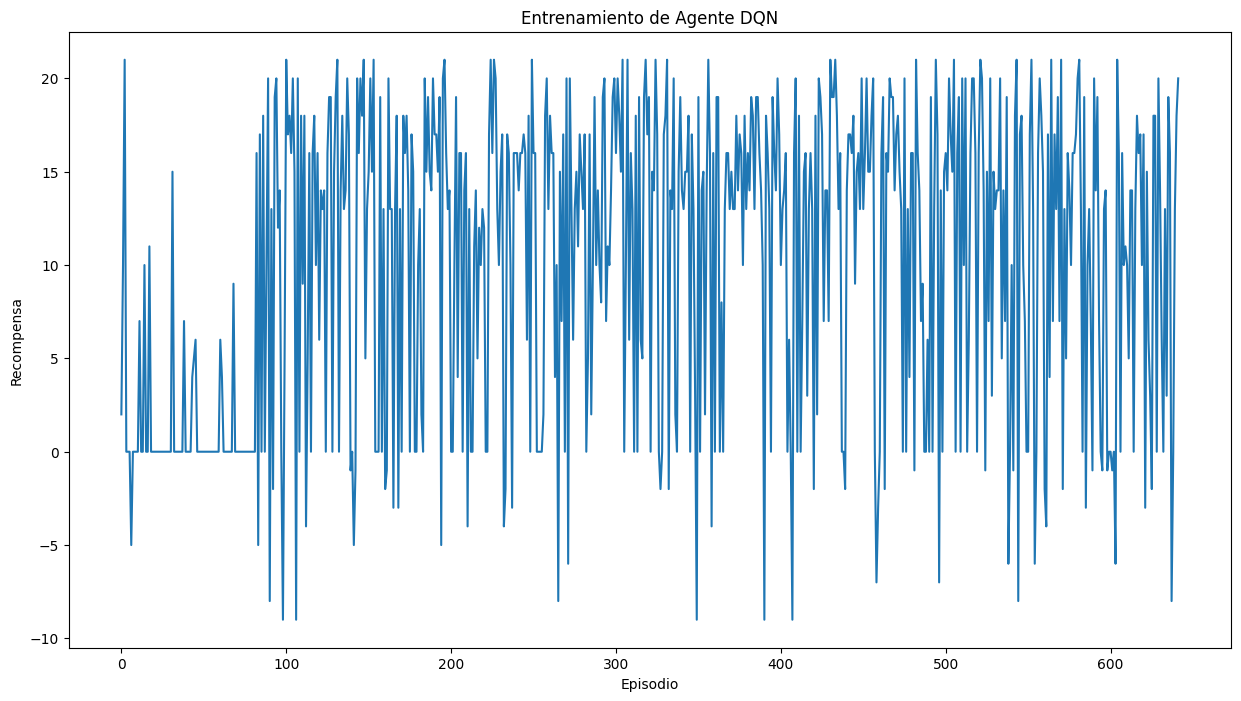

In [ ]:
#@title Grafica entrenamiento de Agente DQN
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plt.plot(rewards_per_episode)
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.title('Entrenamiento de Agente DQN')
plt.show()

In [ ]:
#@title Probar DQN Entrenado contra el Azar
cantidad_probar = 10 # @param {type:"integer"}

if dqnAg is not None:
  compararRtdosAgentes(cantidad_probar, envProblema,
                      dqnAg, randomAgent,
                      "Agente DQN", "Azar")


> Prueba  1 :

**  Resultados de Agente DQN **
 -Recompensa Final = 21.0
 -Secuencia de Acciones = pide carta + pide carta

**  Resultados de Azar **
 -Recompensa Final = 0.0
 -Secuencia de Acciones = se planta

--> Agente DQN (21.0) genera MEJOR resultado que Azar (0.0).

> Prueba  2 :

**  Resultados de Agente DQN **
 -Recompensa Final = 20.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados de Azar **
 -Recompensa Final = 0.0
 -Secuencia de Acciones = se planta

--> Agente DQN (20.0) genera MEJOR resultado que Azar (0.0).

> Prueba  3 :

**  Resultados de Agente DQN **
 -Recompensa Final = 21.0
 -Secuencia de Acciones = pide carta + pide carta + pide carta

**  Resultados de Azar **
 -Recompensa Final = 0.0
 -Secuencia de Acciones = se planta

--> Agente DQN (21.0) genera MEJOR resultado que Azar (0.0).

> Prueba  4 :

**  Resultados de Agente DQN **
 -Recompensa Final = 18.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados d

## Comparar Q-Learning y DQN

In [ ]:

#@title Cargar o Guardar los Agentes Q-Learning y DQN entrenados

# parámetros
directorio_modelos = '/content/gdrive/MyDrive/demosColab/demoRL/Modelos/QBlackjack' #@param {type:"string"}
accion_realizar = "Grabar Modelo" #@param ["-", "Cargar Modelo", "Grabar Modelo"]

if accion_realizar != "-":

  import joblib
  import os

  # Montar Drive
  from google.colab import drive
  drive.mount('/content/gdrive')

  if accion_realizar == "Grabar Modelo":

      # define configuración de agentes
      defArchivosConfig = []
      defArchivosConfig.append( [randomAgent, "Random_agent.joblib", "Agente Random"] )
      defArchivosConfig.append( [qlAgent, "QL_agent.joblib", "Agente Q-Learning"] )
      defArchivosConfig.append( [dqnAg, "DQN_agent.joblib", "Agente DQN"] )

      # si no existe el directorio, lo crea
      if not os.path.isdir(directorio_modelos):
        os.makedirs(directorio_modelos)
      # guarda las clases auxiliares de los agentes entrenados
      for config in defArchivosConfig:
        ar = os.path.join(directorio_modelos, config[1])
        joblib.dump(config[0], ar)
        print("-" + str(config[2]) + " grabado en "+ str(ar))
        if "DQN" in config[2]:
          config[0].save_model(folder=directorio_modelos)

  elif accion_realizar == "Cargar Modelo":

      # define configuración de agentes
      defArchivosConfig = []
      defArchivosConfig.append( [None, "Random_agent.joblib", "Agente Random"] )
      defArchivosConfig.append( [None, "QL_agent.joblib", "Agente Q-Learning"] )
      defArchivosConfig.append( [None, "DQN_agent.joblib", "Agente DQN"] )

      # carga la política del modelo --- el resto no se necesita cargar
      for i in range(len(defArchivosConfig)):
        config = defArchivosConfig[i]
        ar = os.path.join(directorio_modelos, config[1])
        if os.path.isfile(ar):
          infoRecup = joblib.load(ar)
          if "Random" in config[2]:
            randomAgent = infoRecup
          elif "Q-Learning" in config[2]:
            qlAgent = infoRecup
          elif "DQN" in config[2]:
            dqnAg = infoRecup
          else:
              raise ValueError(str(config[2]) + " iteración + " + str(i) +" no definida variable a recuperar!")
          print("-" + str(config[2]) + " recuperado de "+ str(ar))
        else:
          print("- No se encuentra el archivo ", ar)


Mounted at /content/gdrive
-Agente Random grabado en /content/gdrive/MyDrive/IA/demoRL/Modelos/QBlackjack/Random_agent.joblib
-Agente Q-Learning grabado en /content/gdrive/MyDrive/IA/demoRL/Modelos/QBlackjack/QL_agent.joblib
-Agente DQN grabado en /content/gdrive/MyDrive/IA/demoRL/Modelos/QBlackjack/DQN_agent.joblib
  Modelo grabado en '/content/gdrive/MyDrive/IA/demoRL/Modelos/QBlackjack'


In [ ]:
#@title Probar Q-Learning Entrenado contra Agente DQN Entrenado
cantidad_probar = 10 # @param {type:"integer"}

if (dqnAg is not None) and (qlAgent is not None):
  compararRtdosAgentes(cantidad_probar, envProblema,
                      dqnAg, qlAgent,
                      "Agente DQN", "Agente Q-Learning")



> Prueba  1 :

**  Resultados de Agente DQN **
 -Recompensa Final = 17.0
 -Secuencia de Acciones = pide carta + pide carta + pide carta + se planta

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 11.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

--> Agente DQN (17.0) genera MEJOR resultado que Agente Q-Learning (11.0).

> Prueba  2 :

**  Resultados de Agente DQN **
 -Recompensa Final = 15.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 11.0
 -Secuencia de Acciones = pide carta + se planta

--> Agente DQN (15.0) genera MEJOR resultado que Agente Q-Learning (11.0).

> Prueba  3 :

**  Resultados de Agente DQN **
 -Recompensa Final = 14.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

**  Resultados de Agente Q-Learning **
 -Recompensa Final = 14.0
 -Secuencia de Acciones = pide carta + pide carta + se planta

--> Agente DQN (14.0) genera IGUAL resultado que Agente

In [ ]:
#@title Probar Agentes entrenados contra Usuario Humano
#@markdown (notar que agentes no conocen las cartas que le salieron a los otros, sólo su estado actual)
import ipywidgets as widgets
from IPython.display import display, clear_output

def resetear():
  global agentesDescrip, envAgentes, nroPasoAgentes, estadoEnvAgentes, envProblema
  # Inicializar variables
  envAgentes = []
  nroPasoAgentes = []
  estadoEnvAgentes = []
  # Crea los entornos e inicializa variables
  for i in range(len(agentesDescrip)):
    env = envProblema = gym.make( CardGameEnv.getEnvID() )
    env_obs, env_info = env.reset()
    envAgentes.append( env )
    nroPasoAgentes.append( 1 )
    estadoEnvAgentes.append( [env_obs, 0.0] )

def jugar(prefijoJugador, nombreJugador, env, paso, action):
  if paso < 0:
    # no se hace porque ya termino la partida
    return paso
  else:
    # aplica la acción
    env_obs, env_reward, env_terminated, env_truncated, env_info = env.step(action)
    # recupera la observación y muestra el nuevo estado
    if env_info is not None:
      if "lastActionName" in env_info:
        descAccion = env_info["lastActionName"]
      else:
        descAccion = "id:" + str(env_info["lastActionId"])
      if "newCard" in env_info:
        descAccion += " " + posiblesCartas[env_info["newCard"]]
      descEstado = str(env_info["stateName"])
    else:
      descAccion = "¿?"
      descEstado = str(env_obs)
    print(prefijoJugador, "Jugada #" + str(paso), nombreJugador + ":", descAccion, "->", descEstado )
    # ve si termino o sigue
    if env_terminated or env_truncated:
      paso = -1
    else:
      paso = paso + 1
    return paso, [env_obs, env_reward]

def jugarAgentes():
    global agentesDescrip, agentesPolicy, envAgentes, nroPasoAgentes, estadoEnvAgentes
    algunoPuedeSeguirJugando = False
    # inicia jugando primero a los agentes
    for i in range(len(agentesPolicy)):
      # no es humano
      if i != idPosHumano:
        # puede seguir jugando
        if nroPasoAgentes[i] >= 0:
          aux_action_step  = agentesPolicy[i].action( estadoEnvAgentes[i][0] )
          auxPaso, auxEstado = jugar("*", agentesDescrip[i], envAgentes[i], nroPasoAgentes[i], aux_action_step)
          nroPasoAgentes[i] = auxPaso
          estadoEnvAgentes[i] = auxEstado
          algunoPuedeSeguirJugando = algunoPuedeSeguirJugando or (auxPaso >= 0)
    return algunoPuedeSeguirJugando

# define funciones para los botones
def on_buttonReiniciar_clicked(b):
  global agentesDescrip, agentesPolicy, envAgentes, nroPasoAgentes, estadoEnvAgentes
  # se toca botón para reiniciar la partida
  with output:
    clear_output()
    print("\n> Nueva Partida:\n")
    # resetea ambientes
    resetear()
    # inicia jugando primero a los agentes
    jugarAgentes()
    # fuerza que le de la primera carta al humano
    on_buttonPedir_clicked(on_buttonPedir_clicked)

def on_buttonPedir_clicked(b):
  global agentesDescrip, agentesPolicy, envAgentes, nroPasoAgentes, estadoEnvAgentes
  # se toca botón de pedir nueva carta
  with output:
    # juega humano
    if nroPasoAgentes[idPosHumano] >= 0:
      auxPaso, auxEstado = jugar("+", agentesDescrip[idPosHumano], envAgentes[idPosHumano], nroPasoAgentes[idPosHumano], accion_pedirCarta)
      nroPasoAgentes[idPosHumano] = auxPaso
      estadoEnvAgentes[idPosHumano] = auxEstado
    print(" ")
    # juega agentes
    puedenAGSeguir = True
    while puedenAGSeguir:
      puedenAGSeguir = jugarAgentes()
      if nroPasoAgentes[idPosHumano] >= 0:
        # si el humano no terminó, lo hace jugar una vez solamente
        break
    # si todos finalizaron, muestra el estado final
    if not(puedenAGSeguir) and (nroPasoAgentes[idPosHumano] < 0):
      mostrarEstadoFinal()

def on_buttonPlantar_clicked(b):
  global agentesDescrip, agentesPolicy, envAgentes, nroPasoAgentes, estadoEnvAgentes
  # se toca botón de finalizar partida (plantarse)
  with output:
    # juega humano
    if nroPasoAgentes[idPosHumano] >= 0:
      auxPaso, auxEstado = jugar("+", agentesDescrip[idPosHumano], envAgentes[idPosHumano], nroPasoAgentes[idPosHumano], accion_plantar)
      nroPasoAgentes[idPosHumano] = auxPaso
      estadoEnvAgentes[idPosHumano] = auxEstado
    print(" ")
    # juega agentes hasta que terminen
    puedenAGSeguir = True
    while puedenAGSeguir:
      puedenAGSeguir = jugarAgentes()
    # muesta el estado final
    mostrarEstadoFinal()
    print("\n")

def mostrarEstadoFinal():
    global agentesDescrip, agentesPolicy, envAgentes, nroPasoAgentes, estadoEnvAgentes
    # muestra estado final
    print("\n> Resultados: ")
    rewL = []
    for i in range(len(agentesDescrip)):
      r = int( estadoEnvAgentes[i][1] )
      rewL.append( r )
      resul = "%s" % r
      if (r > 21) or (r < 0):
        resul = resul + "!"
      print("\t " + agentesDescrip[i] + ": " + resul)
    # determina mejor resultado
    mejorPuntaje =  rewL[ np.argmax(rewL) ]
    cantGana = 0
    quienesGana = ""
    for i in range(len(rewL)):
        if mejorPuntaje == rewL[i]:
          cantGana = cantGana + 1
          if cantGana > 1:
            quienesGana = quienesGana + " & "
          quienesGana = quienesGana + agentesDescrip[i]
    if cantGana > 1:
      quienesGana = "GANAN: " + quienesGana
    else:
      quienesGana = "GANA: " + quienesGana
    print("\t = " + quienesGana)
    print("\n")
    return


# inicializa variables auxiliares
idPosHumano = 0
agentesDescrip = []
agentesPolicy = []
# humano
agentesDescrip.append( "Humano" )
agentesPolicy.append( None )
# ql
if (qlAgent is not None) and (qlAgent._QtableEntrenada):
  agentesDescrip.append( "Agente QL" )
  agentesPolicy.append( qlAgent )
# dqn
if dqnAg is not None:
  agentesDescrip.append( "Agente DQN" )
  agentesPolicy.append( dqnAg )
resetear()

# define botones
buttonPedir = widgets.Button(description="Dame Otra Carta")
buttonPlantar = widgets.Button(description="Plantarse")
buttonReiniciar = widgets.Button(description="Reiniciar Partida")
output = widgets.Output()
buttonReiniciar.on_click(on_buttonReiniciar_clicked)
buttonPlantar.on_click(on_buttonPlantar_clicked)
buttonPedir.on_click(on_buttonPedir_clicked)

# comienza a jugar
on_buttonReiniciar_clicked(buttonReiniciar)

# muestra botones
display(buttonPedir, buttonPlantar, buttonReiniciar, output)



Button(description='Dame Otra Carta', style=ButtonStyle())

Button(description='Plantarse', style=ButtonStyle())

Button(description='Reiniciar Partida', style=ButtonStyle())

Output()